# Waveform modelling with KAN

This notebook evaluates the numpy-exported KAN model coefficient set in `KAN_model/KAN_sxs_numpy.json` and recreates the waveform comparisons, mismatch summaries, detector-weighted study, and sparse-coverage stress diagnostics used by this repository.

The workflow intentionally starts from the exported waveform rather than from a training checkpoint. Downloaded SXS and NRSur data are cached under `plot_utilities/waveform_data/`, which is excluded from version control.

## Setup

The analysis utilities download external waveform resources when needed. The SXS split itself is fixed by `BBH_ID.text`.

In [1]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
FIGURES = ROOT / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

from KAN_utilities import KAN_Waveform as KW
from plot_utilities import waveform_plotting
from plot_utilities.consistent_conditioning_mismatch import compute_mismatches as compute_flat_mismatches
from plot_utilities.conditioning_check_mismatch import compute_mismatches as compute_conditioning_check
from plot_utilities import detector_weighted_mismatch as detector_mass
from plot_utilities import stress_detector_weighted_mismatch as stress_plot
from IPython.display import clear_output

print("Repository root", ROOT)
print("KAN coefficient file", ROOT / "KAN_model" / "KAN_sxs_numpy.json")
print("Declared Mf support", KW.model_domain().get("Mf"))

Repository root /Users/arghyachattopadhyay/Library/CloudStorage/Dropbox/Machinic/KAN_PyCBC/KAN_GitHub_v1
KAN coefficient file /Users/arghyachattopadhyay/Library/CloudStorage/Dropbox/Machinic/KAN_PyCBC/KAN_GitHub_v1/KAN_model/KAN_sxs_numpy.json
Declared Mf support [0.004, 0.15]


## Fixed SXS IDs

The training, validation, interpolation-test, stress, preprocessing-exclusion, and strict NRSur comparison lists are recorded in `BBH_ID.text`. The paper comparisons below use the 75-system interpolation test set. NRSur7dq4 is evaluated only for the 71 systems inside its strict calibration domain.

In [2]:
def read_id_sections(path="BBH_ID.text"):
    sections = {}
    current = None
    for raw in Path(path).read_text().splitlines():
        line = raw.strip()
        if line.startswith("[") and line.endswith("]"):
            current = line[1:-1]
            sections[current] = []
        elif current is not None and line.startswith("SXS:BBH:"):
            sections[current].append(line)
    return sections

ID_SECTIONS = read_id_sections()
TRAIN_IDS = ID_SECTIONS["TRAINING — 280"]
VALIDATION_IDS = ID_SECTIONS["VALIDATION — 75"]
INTERPOLATION_TEST_IDS = ID_SECTIONS["INTERPOLATION TEST — 75"]
STRESS_IDS = ID_SECTIONS["STRESS / SPARSE-COVERAGE — 30"]
NRSUR7DQ4_EXCLUDED_TEST_IDS = set(
    ID_SECTIONS["NRSUR7DQ4 COMPARISON EXCLUDED FROM THE 75-SYSTEM INTERPOLATION TEST — 4"]
)
NRSUR_COMMON_TEST_IDS = [
    sid for sid in INTERPOLATION_TEST_IDS
    if sid not in NRSUR7DQ4_EXCLUDED_TEST_IDS
]

print("training", len(TRAIN_IDS))
print("validation", len(VALIDATION_IDS))
print("interpolation test", len(INTERPOLATION_TEST_IDS))
print("stress", len(STRESS_IDS))
print("NRSur-common interpolation test", len(NRSUR_COMMON_TEST_IDS))

training 280
validation 75
interpolation test 75
stress 30
NRSur-common interpolation test 71


## Representative waveform comparison

The example below reproduces the waveform-level comparison for `SXS:BBH:0198` at a total mass of `50 M_sun` and luminosity distance of `400 Mpc`. The same utility can be called for any ID in the interpolation set. The four systems outside the strict NRSur7dq4 domain should not be requested in a four-model comparison.

Loading SXS simulations using latest tag 'v3.0.0', published at 2025-05-14T18:17:30Z.


/opt/homebrew/Caskroom/miniforge/base/envs/Kansxs/lib/python3.11/importlib/__init__.py:126: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  return _bootstrap._gcd_import(name[level:], package, level)


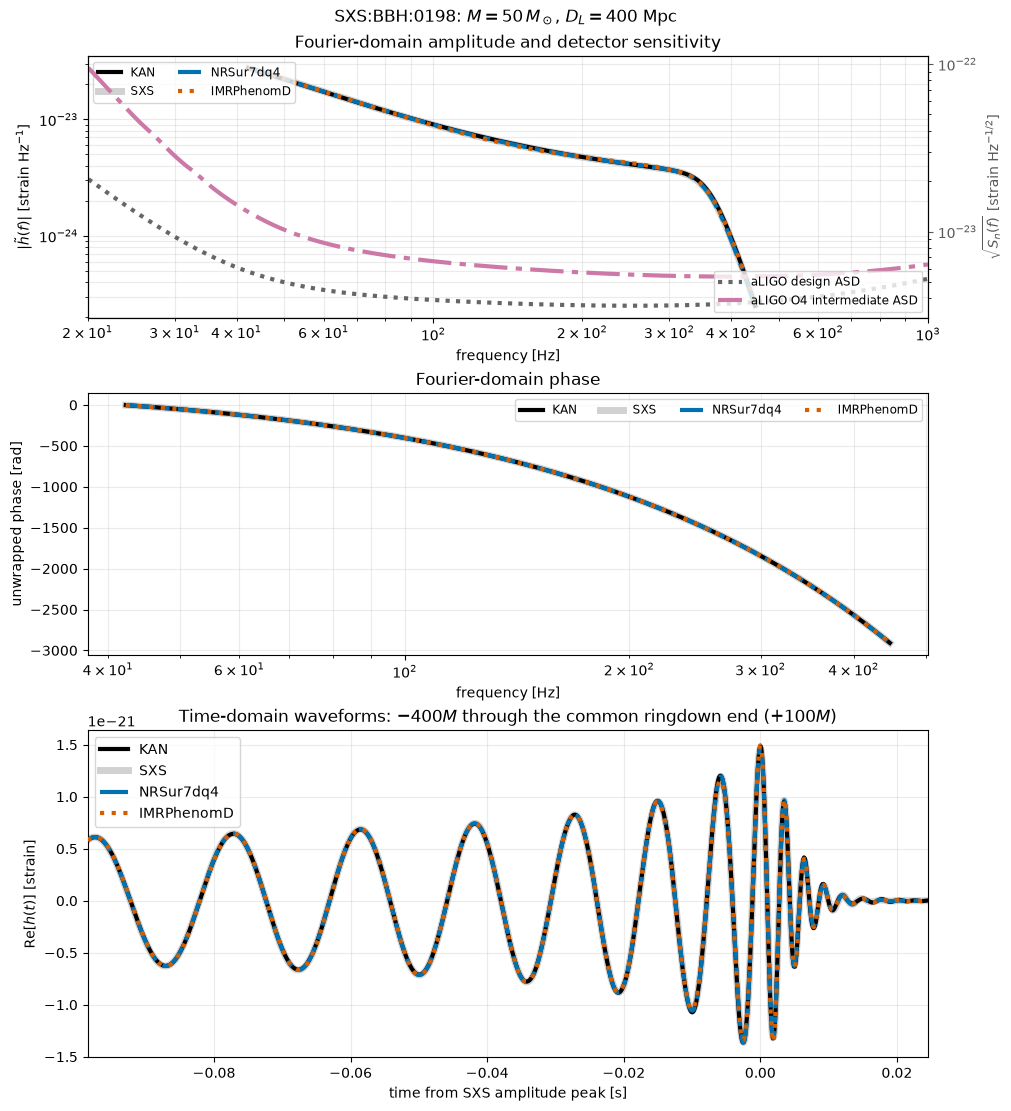

saved /Users/arghyachattopadhyay/Library/CloudStorage/Dropbox/Machinic/KAN_PyCBC/KAN_GitHub_v1/figures/representative_waveform.png


In [3]:
REPRESENTATIVE_ID = "SXS:BBH:0198"

representative = waveform_plotting.plot_waveforms(
    REPRESENTATIVE_ID,
    total_mass_msun=50.0,
    luminosity_distance_mpc=400.0,
    output_path=FIGURES / "representative_waveform.png",
    show=True,
)

print("saved", FIGURES / "representative_waveform.png")

## Flat-noise mismatch distribution

For each interpolation-test system we compare the exported KAN waveform with the training-conditioned SXS reference. IMRPhenomD and the TaylorF2/Newtonian analytic backbone are evaluated on all 75 systems. NRSur7dq4 is evaluated only on the 71-system strict common subset. All mismatches are maximized over relative time and constant phase.

In [4]:
KAN_MM = []
KAN_MM71 = []
NRSUR_MM = []
IMRPHENOMD_MM = []
IMRPHENOMD_MM71 = []
TAYLORF2_MM = []
TAYLORF2_MM71 = []

for index, sxs_id in enumerate(INTERPOLATION_TEST_IDS, start=1):
    clear_output(wait=True)
    print(f"[{index}/{len(INTERPOLATION_TEST_IDS)}] {sxs_id}")

    result_kan = compute_flat_mismatches(
        sxs_id, 600, models="KAN", progress=False
    )
    result_phenom = compute_flat_mismatches(
        sxs_id, 600, models="IMRPhenomD", progress=False
    )
    result_pn = compute_flat_mismatches(
        sxs_id, 600, models="PN Backbone", progress=False
    )

    kan_value = result_kan["mismatches"]["KAN"]["mismatch"]
    phenom_value = result_phenom["mismatches"]["IMRPhenomD"]["mismatch"]
    pn_value = result_pn["mismatches"]["TaylorF2 PN backbone"]["mismatch"]

    KAN_MM.append(kan_value)
    IMRPHENOMD_MM.append(phenom_value)
    TAYLORF2_MM.append(pn_value)

    if sxs_id not in NRSUR7DQ4_EXCLUDED_TEST_IDS:
        result_nrsur = compute_flat_mismatches(
            sxs_id, 600, models="NRSur7dq4", progress=False
        )
        NRSUR_MM.append(result_nrsur["mismatches"]["NRSur7dq4"]["mismatch"])
        KAN_MM71.append(kan_value)
        IMRPHENOMD_MM71.append(phenom_value)
        TAYLORF2_MM71.append(pn_value)

print()

[75/75] SXS:BBH:4434



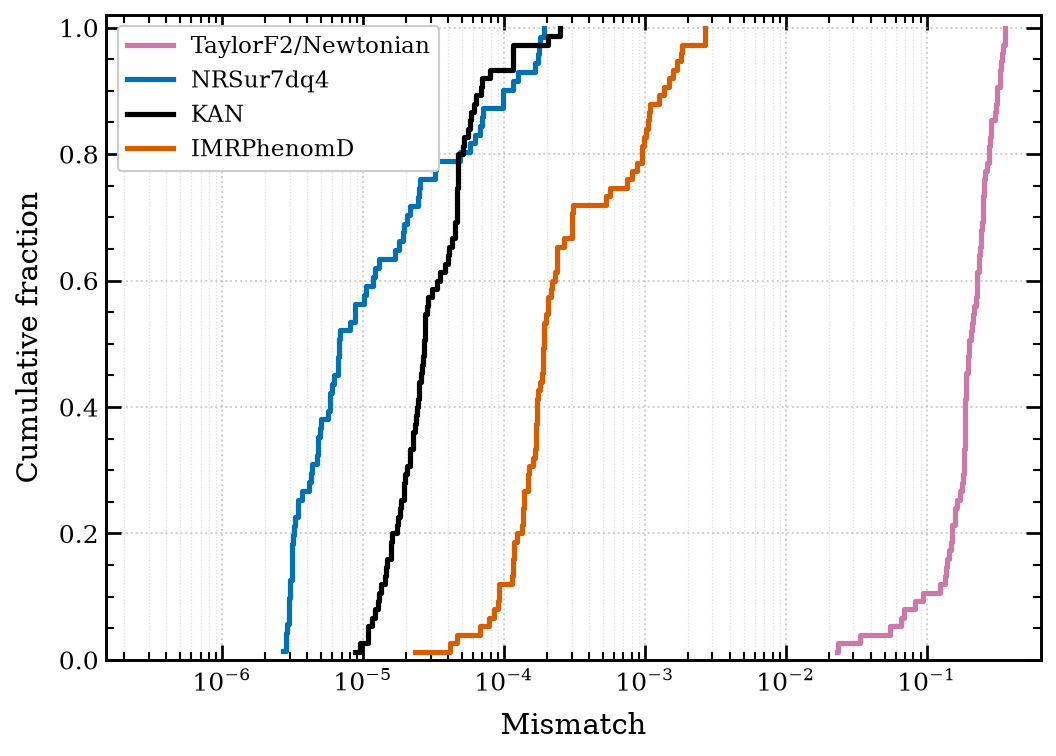

In [5]:
import matplotlib as mpl
from matplotlib.ticker import LogLocator, NullFormatter, MultipleLocator


def plot_cdf(ax, values, label, **plot_kwargs):
    values = np.asarray(values, dtype=float)
    values = np.sort(values[np.isfinite(values) & (values > 0)])
    cumulative_fraction = np.arange(1, len(values) + 1) / len(values)
    ax.step(values, cumulative_fraction, where="post", label=label, **plot_kwargs)


paper_style = {
    "font.family": "serif",
    "mathtext.fontset": "stix",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.linewidth": 1.4,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
    "savefig.dpi": 600,
}

with mpl.rc_context(paper_style):
    fig, ax = plt.subplots(figsize=(7.2, 5.2), dpi=150)
    plot_cdf(ax, TAYLORF2_MM, "TaylorF2/Newtonian", linewidth=2.5, color="#CC79A7")
    plot_cdf(ax, NRSUR_MM, "NRSur7dq4", linewidth=2.5, color="#0072B2")
    plot_cdf(ax, KAN_MM, "KAN", linewidth=2.5, color="black")
    plot_cdf(ax, IMRPHENOMD_MM, "IMRPhenomD", linewidth=2.5, color="#D55E00")

    ax.set_xscale("log")
    ax.set_ylim(0, 1.02)
    ax.set_xlabel("Mismatch", labelpad=7)
    ax.set_ylabel("Cumulative fraction", labelpad=7)
    ax.xaxis.set_major_locator(LogLocator(base=10))
    ax.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1))
    ax.xaxis.set_minor_formatter(NullFormatter())
    ax.yaxis.set_major_locator(MultipleLocator(0.2))
    ax.yaxis.set_minor_locator(MultipleLocator(0.05))
    ax.tick_params(axis="both", which="major", direction="in", length=7, width=1.3, top=True, right=True)
    ax.tick_params(axis="both", which="minor", direction="in", length=4, width=1.0, top=True, right=True)
    for spine in ax.spines.values():
        spine.set_linewidth(1.4)
    ax.grid(True, which="major", linestyle=":", linewidth=0.9, alpha=0.65)
    ax.grid(True, which="minor", axis="x", linestyle=":", linewidth=0.6, alpha=0.4)
    ax.set_axisbelow(True)

    valid = np.concatenate([
        np.asarray(NRSUR_MM), np.asarray(KAN_MM),
        np.asarray(IMRPHENOMD_MM), np.asarray(TAYLORF2_MM)
    ])
    valid = valid[np.isfinite(valid) & (valid > 0)]
    ax.set_xlim(left=np.min(valid) / 18)
    ax.legend(loc="upper left", frameon=True, framealpha=1.0, facecolor="white")
    fig.tight_layout()
    fig.savefig(FIGURES / "mismatch_cdf.pdf", bbox_inches="tight")
    plt.show()

In [6]:
flat_summary = {}


# ============================================================
# 1. Full 75-system interpolation-test set
#    KAN, IMRPhenomD, and TaylorF2 evaluated together
#    on identical per-system common support
# ============================================================

full_test_arrays = {
    "KAN": np.asarray(KAN_MM, dtype=float),
    "IMRPhenomD": np.asarray(IMRPHENOMD_MM, dtype=float),
    "TaylorF2": np.asarray(TAYLORF2_MM, dtype=float),
}

flat_summary["full_interpolation_test"] = {}

for name, values in full_test_arrays.items():

    finite = values[np.isfinite(values)]

    flat_summary["full_interpolation_test"][name] = {
        "n": int(len(finite)),
        "median": float(np.median(finite)),
        "p90": float(np.percentile(finite, 90)),
        "max": float(np.max(finite)),
    }

    print(
        f"{name} [full test]: "
        f"N={len(finite)}, "
        f"median={np.median(finite):.6g}, "
        f"p90={np.percentile(finite, 90):.6g}, "
        f"max={np.max(finite):.6g}"
    )


# ------------------------------------------------------------
# Paired KAN vs IMRPhenomD comparison on all 75 systems
# ------------------------------------------------------------

kan75 = full_test_arrays["KAN"]
phenom75 = full_test_arrays["IMRPhenomD"]

valid = np.isfinite(kan75) & np.isfinite(phenom75)

kan_wins = int(np.sum(kan75[valid] < phenom75[valid]))
phenom_wins = int(np.sum(phenom75[valid] < kan75[valid]))
ties = int(np.sum(kan75[valid] == phenom75[valid]))
n_test = int(np.sum(valid))

kan_win_fraction = kan_wins / n_test
phenom_win_fraction = phenom_wins / n_test

flat_summary["KAN_vs_IMRPhenomD_full"] = {
    "KAN_lower_mismatch": kan_wins,
    "IMRPhenomD_lower_mismatch": phenom_wins,
    "ties": ties,
    "systems": n_test,
    "KAN_win_fraction": float(kan_win_fraction),
    "KAN_win_percentage": float(100.0 * kan_win_fraction),
    "IMRPhenomD_win_fraction": float(phenom_win_fraction),
    "IMRPhenomD_win_percentage": float(100.0 * phenom_win_fraction),
}

print(
    f"\nKAN vs IMRPhenomD [full test]: "
    f"{kan_wins} KAN wins ({100*kan_win_fraction:.1f}%), "
    f"{phenom_wins} IMRPhenomD wins ({100*phenom_win_fraction:.1f}%), "
    f"{ties} ties out of {n_test} systems."
)


# ============================================================
# 2. 71-system NRSur7dq4 common subset
#    All models evaluated together on the same four-waveform
#    common support for each SXS system
# ============================================================

common_arrays = {
    "KAN": np.asarray(KAN_MM71, dtype=float),
    "NRSur7dq4": np.asarray(NRSUR_MM, dtype=float),
    "IMRPhenomD": np.asarray(IMRPHENOMD_MM71, dtype=float),
    "TaylorF2": np.asarray(TAYLORF2_MM71, dtype=float),
}

flat_summary["nrsur_common_subset"] = {}

for name, values in common_arrays.items():

    finite = values[np.isfinite(values)]

    flat_summary["nrsur_common_subset"][name] = {
        "n": int(len(finite)),
        "median": float(np.median(finite)),
        "p90": float(np.percentile(finite, 90)),
        "max": float(np.max(finite)),
    }

    print(
        f"{name} [common subset]: "
        f"N={len(finite)}, "
        f"median={np.median(finite):.6g}, "
        f"p90={np.percentile(finite, 90):.6g}, "
        f"max={np.max(finite):.6g}"
    )


# ------------------------------------------------------------
# Paired KAN vs NRSur7dq4 on the 71-system common subset
# ------------------------------------------------------------

kan71 = common_arrays["KAN"]
nrsur71 = common_arrays["NRSur7dq4"]

valid = np.isfinite(kan71) & np.isfinite(nrsur71)

kan_wins = int(np.sum(kan71[valid] < nrsur71[valid]))
nrsur_wins = int(np.sum(nrsur71[valid] < kan71[valid]))
ties = int(np.sum(kan71[valid] == nrsur71[valid]))
n_common = int(np.sum(valid))

kan_win_fraction = kan_wins / n_common
nrsur_win_fraction = nrsur_wins / n_common

flat_summary["KAN_vs_NRSur7dq4_common"] = {
    "KAN_lower_mismatch": kan_wins,
    "NRSur7dq4_lower_mismatch": nrsur_wins,
    "ties": ties,
    "systems": n_common,
    "KAN_win_fraction": float(kan_win_fraction),
    "KAN_win_percentage": float(100.0 * kan_win_fraction),
    "NRSur7dq4_win_fraction": float(nrsur_win_fraction),
    "NRSur7dq4_win_percentage": float(100.0 * nrsur_win_fraction),
}

print(
    f"\nKAN vs NRSur7dq4 [common subset]: "
    f"{kan_wins} KAN wins ({100*kan_win_fraction:.1f}%), "
    f"{nrsur_wins} NRSur7dq4 wins ({100*nrsur_win_fraction:.1f}%), "
    f"{ties} ties out of {n_common} systems."
)


# ------------------------------------------------------------
# Paired KAN vs IMRPhenomD on the same 71-system common subset
# ------------------------------------------------------------

phenom71 = common_arrays["IMRPhenomD"]

valid = np.isfinite(kan71) & np.isfinite(phenom71)

kan_wins = int(np.sum(kan71[valid] < phenom71[valid]))
phenom_wins = int(np.sum(phenom71[valid] < kan71[valid]))
ties = int(np.sum(kan71[valid] == phenom71[valid]))
n_common = int(np.sum(valid))

kan_win_fraction = kan_wins / n_common
phenom_win_fraction = phenom_wins / n_common

flat_summary["KAN_vs_IMRPhenomD_common"] = {
    "KAN_lower_mismatch": kan_wins,
    "IMRPhenomD_lower_mismatch": phenom_wins,
    "ties": ties,
    "systems": n_common,
    "KAN_win_fraction": float(kan_win_fraction),
    "KAN_win_percentage": float(100.0 * kan_win_fraction),
    "IMRPhenomD_win_fraction": float(phenom_win_fraction),
    "IMRPhenomD_win_percentage": float(100.0 * phenom_win_fraction),
}

print(
    f"\nKAN vs IMRPhenomD [common subset]: "
    f"{kan_wins} KAN wins ({100*kan_win_fraction:.1f}%), "
    f"{phenom_wins} IMRPhenomD wins ({100*phenom_win_fraction:.1f}%), "
    f"{ties} ties out of {n_common} systems."
)


# ============================================================
# Save
# ============================================================

(FIGURES / "flat_noise_summary.json").write_text(
    json.dumps(flat_summary, indent=2) + "\n"
)

# flat_summary

KAN [full test]: N=75, median=2.69998e-05, p90=6.63684e-05, max=0.000246942
IMRPhenomD [full test]: N=75, median=0.000191437, p90=0.00130944, max=0.00267049
TaylorF2 [full test]: N=75, median=0.198668, p90=0.315208, max=0.356197

KAN vs IMRPhenomD [full test]: 73 KAN wins (97.3%), 2 IMRPhenomD wins (2.7%), 0 ties out of 75 systems.
KAN [common subset]: N=71, median=2.69998e-05, p90=6.31642e-05, max=0.000203769
NRSur7dq4 [common subset]: N=71, median=6.74972e-06, p90=9.81655e-05, max=0.000191287
IMRPhenomD [common subset]: N=71, median=0.000188316, p90=0.0013511, max=0.00267049
TaylorF2 [common subset]: N=71, median=0.195236, p90=0.315211, max=0.356197

KAN vs NRSur7dq4 [common subset]: 21 KAN wins (29.6%), 50 NRSur7dq4 wins (70.4%), 0 ties out of 71 systems.

KAN vs IMRPhenomD [common subset]: 69 KAN wins (97.2%), 2 IMRPhenomD wins (2.8%), 0 ties out of 71 systems.


2081

In [7]:
kan75 = np.asarray(KAN_MM)
phenom75 = np.asarray(IMRPHENOMD_MM)

for sxs_id, kan, phenom in zip(
    INTERPOLATION_TEST_IDS, kan75, phenom75
):
    if phenom < kan:
        print(
            sxs_id,
            f"KAN = {kan:.8e}",
            f"IMRPhenomD = {phenom:.8e}",
            f"ratio KAN/PhenomD = {kan/phenom:.3f}",
        )

SXS:BBH:1132 KAN = 2.03768949e-04 IMRPhenomD = 1.36425470e-04 ratio KAN/PhenomD = 1.494
SXS:BBH:3909 KAN = 4.50208751e-05 IMRPhenomD = 2.33777449e-05 ratio KAN/PhenomD = 1.926


## Conditioning sensitivity

This diagnostic repeats the comparison using a minimally conditioned SXS reference while keeping the comparison band fixed. It is intended to isolate sensitivity to the time-domain treatment rather than to define the headline mismatch.

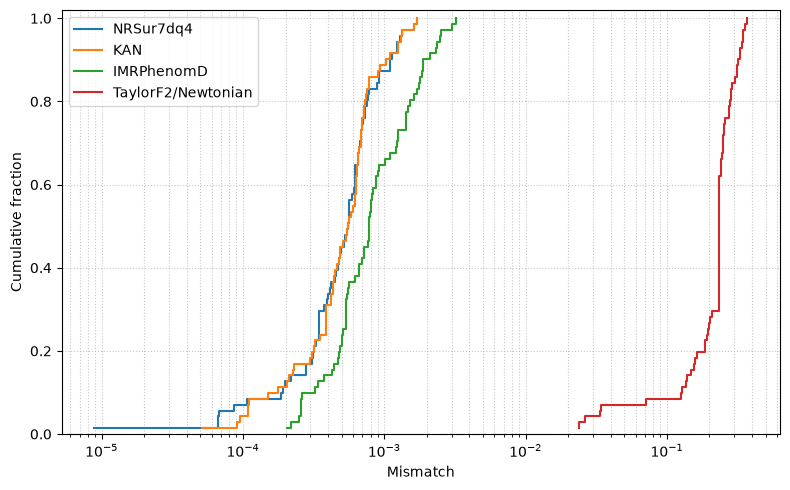

In [8]:
KAN_RAW_MM = []
NRSUR_RAW_MM = []
IMRPHENOMD_RAW_MM = []
TAYLORF2_RAW_MM = []

for sxs_id in NRSUR_COMMON_TEST_IDS:
    result = compute_conditioning_check(sxs_id, 600, progress=False)
    KAN_RAW_MM.append(result["mismatches"]["KAN"]["mismatch"])
    NRSUR_RAW_MM.append(result["mismatches"]["NRSur7dq4"]["mismatch"])
    IMRPHENOMD_RAW_MM.append(result["mismatches"]["IMRPhenomD"]["mismatch"])
    TAYLORF2_RAW_MM.append(result["mismatches"]["TaylorF2 PN backbone"]["mismatch"])

fig, ax = plt.subplots(figsize=(8, 5))
for values, label in [
    (NRSUR_RAW_MM, "NRSur7dq4"),
    (KAN_RAW_MM, "KAN"),
    (IMRPHENOMD_RAW_MM, "IMRPhenomD"),
    (TAYLORF2_RAW_MM, "TaylorF2/Newtonian"),
]:
    values = np.sort(np.asarray(values, dtype=float))
    ax.step(values, np.arange(1, len(values)+1)/len(values), where="post", label=label)
ax.set_xscale("log")
ax.set_ylim(0, 1.02)
ax.set_xlabel("Mismatch")
ax.set_ylabel("Cumulative fraction")
ax.legend()
ax.grid(True, which="both", linestyle=":", alpha=0.7)
fig.tight_layout()
fig.savefig(FIGURES / "conditioning_sensitivity_cdf.pdf", bbox_inches="tight")
plt.show()

## Detector-weighted mismatch versus total mass

The next cell evaluates the 71-system strict common subset using detector weighting over a sequence of total masses and writes the publication-style mass-dependence figure.

[1/75] SXS:BBH:0198
[2/75] SXS:BBH:0304
[3/75] SXS:BBH:0310
[4/75] SXS:BBH:0327
[5/75] SXS:BBH:0354
[6/75] SXS:BBH:0371
[7/75] SXS:BBH:0382
[8/75] SXS:BBH:0389
[9/75] SXS:BBH:0398
[10/75] SXS:BBH:0407
[11/75] SXS:BBH:0412
[12/75] SXS:BBH:0451
[13/75] SXS:BBH:0465
[14/75] SXS:BBH:0475
[15/75] SXS:BBH:0488
[16/75] SXS:BBH:0559
[17/75] SXS:BBH:0584
[18/75] SXS:BBH:0593
[19/75] SXS:BBH:0599
[20/75] SXS:BBH:1132
[21/75] SXS:BBH:1142
[22/75] SXS:BBH:1143
[23/75] SXS:BBH:1153
[24/75] SXS:BBH:1154
[25/75] SXS:BBH:1155
[26/75] SXS:BBH:1220
  skipped from NRSur-common catalogue because q=4.00091381923 is outside the strict NRSur7dq4 calibration q<=4; extrapolation is disabled.
[27/75] SXS:BBH:1387
[28/75] SXS:BBH:1476
[29/75] SXS:BBH:1489
[30/75] SXS:BBH:1490
[31/75] SXS:BBH:1504
[32/75] SXS:BBH:1511
[33/75] SXS:BBH:1906
[34/75] SXS:BBH:2087
[35/75] SXS:BBH:2091
[36/75] SXS:BBH:2092
[37/75] SXS:BBH:2118
[38/75] SXS:BBH:2120
[39/75] SXS:BBH:2123
[40/75] SXS:BBH:2124
[41/75] SXS:BBH:2128
[42/75] S

,model,total_mass_msun,median,p90,systems
0,IMRPhenomD,60.0,0.000237,0.001481,71
1,IMRPhenomD,70.0,0.000246,0.001482,71
2,IMRPhenomD,80.0,0.000253,0.001460,71
3,IMRPhenomD,90.0,0.000257,0.001417,71
4,IMRPhenomD,100.0,0.000258,0.001344,71
5,IMRPhenomD,110.0,0.000253,0.001259,71
6,IMRPhenomD,120.0,0.000247,0.001118,71
7,KAN,60.0,0.000032,0.000059,71
8,KAN,70.0,0.000033,0.000063,71
9,KAN,80.0,0.000035,0.000068,71


Skipped systems {'SXS:BBH:1220': 'q=4.00091381923 is outside the strict NRSur7dq4 calibration q<=4; extrapolation is disabled.', 'SXS:BBH:2385': 'q=4.99947699524 is outside the strict NRSur7dq4 calibration q<=4; extrapolation is disabled.', 'SXS:BBH:2486': 'q=5.50003563689 is outside the strict NRSur7dq4 calibration q<=4; extrapolation is disabled.', 'SXS:BBH:2499': 'q=4.00002063035 is outside the strict NRSur7dq4 calibration q<=4; extrapolation is disabled.'}


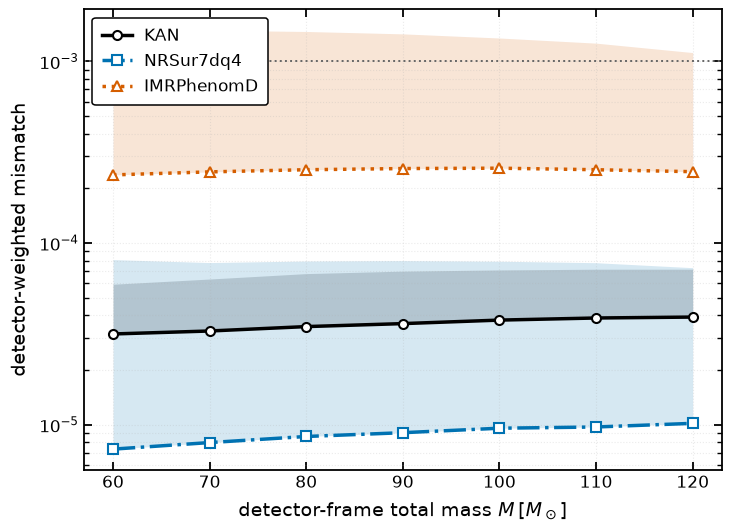

In [9]:
mass_results, skipped = detector_mass.compute_interpolation_catalogue(
    masses_msun=[60, 70, 80, 90, 100, 110, 120],
    download=True,
)

mass_figure, mass_axis, mass_summary = detector_mass.plot_mismatch_vs_mass(
    mass_results,
    output_path=FIGURES / "detector_weighted_mismatch_vs_mass.pdf",
)

display(mass_summary)
print("Skipped systems", skipped)
mass_summary.to_csv(FIGURES / "detector_weighted_mismatch_vs_mass.csv", index=False)

## Sparse-coverage stress sample

The stress set contains 30 systems in sparsely sampled portions of the NR parameter space. It is reported separately from the interpolation test set and is not used for model selection.

Stress [01/30] SXS:BBH:0203
Stress [02/30] SXS:BBH:0204


100%|██████████| 5.22M/5.22M [00:13<00:00, 400kB/s]


Stress [03/30] SXS:BBH:0205


100%|██████████| 3.45M/3.45M [00:04<00:00, 725kB/s] 


Stress [04/30] SXS:BBH:0206


...

Stress [21/30] SXS:BBH:2143
Stress [22/30] SXS:BBH:2147
Stress [23/30] SXS:BBH:2148
Stress [24/30] SXS:BBH:2150
Stress [25/30] SXS:BBH:2156
Stress [26/30] SXS:BBH:2159


100%|██████████| 2.79M/2.79M [00:02<00:00, 1.08MB/s]


Stress [27/30] SXS:BBH:2186


100%|██████████| 2.92M/2.92M [00:08<00:00, 357kB/s]


Stress [28/30] SXS:BBH:2208
Stress [29/30] SXS:BBH:2209
Stress [30/30] SXS:BBH:2212

Detector-weighted mismatch statistics (finite available systems per model)
Model              N  Excluded         Median   90th percentile
KAN               30         0   1.042810e-04      1.195421e-03
NRSur7dq4         18        12   3.711171e-05      1.362676e-04
IMRPhenomD        30         0   1.516480e-03      4.876808e-03


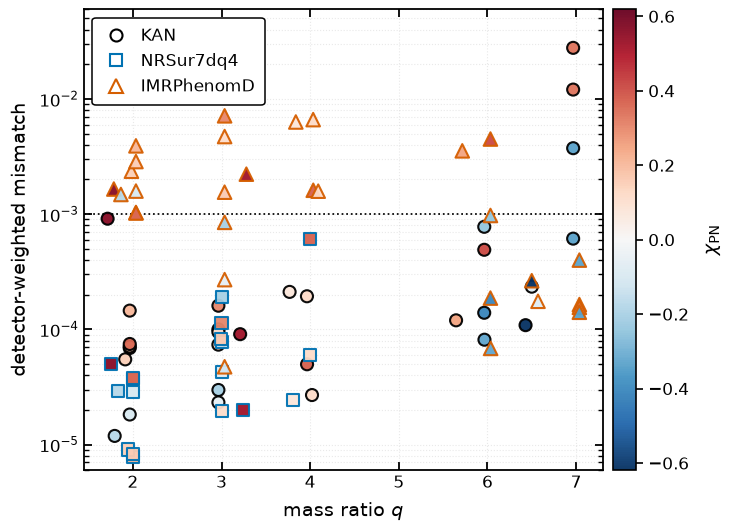


Detector-weighted mismatch statistics (finite available systems per model)
Model              N  Excluded         Median   90th percentile
KAN               30         0   1.042810e-04      1.195421e-03
NRSur7dq4         18        12   3.711171e-05      1.362676e-04
IMRPhenomD        30         0   1.516480e-03      4.876808e-03


In [10]:
stress_result = stress_plot.compute_and_plot(
    total_mass_msun=60.0,
    sxs_ids=STRESS_IDS,
    output_path=FIGURES / "stress_q_chi_pn_colorbar.pdf",
    json_path=FIGURES / "stress_q_chi_pn_results.json",
    show=True,
)

stress_catalogue = stress_plot.load_catalogue(FIGURES / "stress_q_chi_pn_results.json")
stress_plot.print_mismatch_summary(stress_catalogue)

## Output inventory

After a complete run, `figures/` contains the recreated figures and machine-readable numerical summaries. The large waveform data downloaded during the run remain under `plot_utilities/waveform_data/` and are intentionally excluded from Git.

In [11]:
for path in sorted(FIGURES.glob("*")):
    print(path.name)

conditioning_sensitivity_cdf.pdf
detector_weighted_mismatch_vs_mass.csv
detector_weighted_mismatch_vs_mass.pdf
flat_noise_summary.json
mismatch_cdf.pdf
representative_waveform.png
stress_q_chi_pn_colorbar.pdf
stress_q_chi_pn_results.json
